[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MarcoBattiato/PH6721-Deep-Learning-with-Python/blob/main/Classes/Class_3/03C-Regularization.ipynb)

# 03C — Regularization
(by Marco Battiato. For questions/errors/bugs/typos report, please email at marco.battiato.teaching@gmail.com)

**PH6721 — Deep Learning with Python**

**Class 3, Notebook C — Hour 3**

**Instructor:** Marco Battiato (formerly Nanyang Assistant Professor @ Nanyang Technological University)

**email:**  marco.battiato.teaching@gmail.com

**In Person Classes:**  Wednesday 6:30pm - 9:45pm

**Consultation:** remote consultations are to be arranged by writing to marco.battiato.teaching@gmail.com

`03B` ended with a diagnosis and only two cures. When variance dominates, either collect more data —
usually impossible — or reduce the model's flexibility. And the only way we had of reducing
flexibility was to lower the polynomial degree, which is a crude instrument: degree 3 and degree 4
are the nearest available settings, and there is nothing in between.

This notebook replaces that discrete choice with a continuous dial, and in doing so settles several
debts left open since Class 2.

## Learning Objectives

By the end of this notebook, students should be able to:

- explain regularization as a penalty on coefficient size, and why that reduces variance;
- state why features must be on comparable scales before any penalty is applied;
- distinguish **ridge** (L2) from **lasso** (L1), and say why only one of them sets coefficients
  to exactly zero;
- read a coefficient path;
- choose a regularization strength by cross-validation, using `GridSearchCV` over a pipeline;
- explain the `C` parameter of `LogisticRegression`, and why every fit in `02B` was regularized.

## Where this sits in the pipeline

The same map as `02A` and `02B`. Ridge and lasso change one box — the penalty — and that single
change reaches four other steps, which is why this notebook lights up more of the map than a new
method usually does.

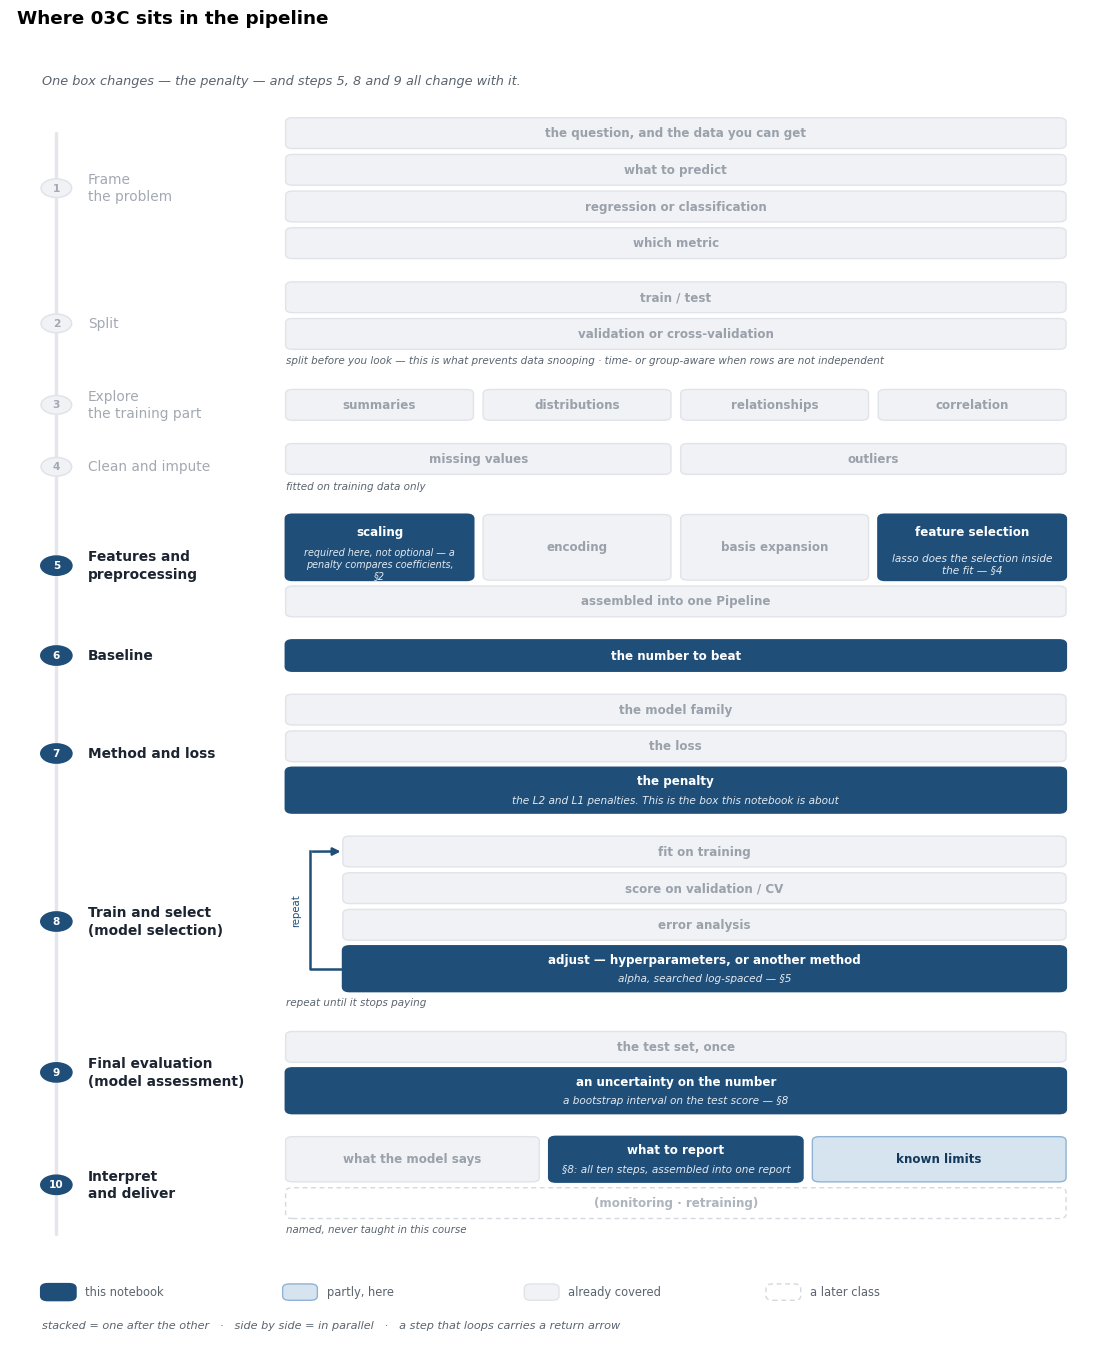

In [ ]:
# Infrastructure, not material. The map below is drawn by one helper file kept with
# the course; Colab has no copy of the repository, so fetch it when it is not already here.
import os, sys, urllib.request
import matplotlib.pyplot as plt

for folder in (".", "..", "../.."):
    if os.path.exists(f"{folder}/pipeline_map.py"):
        sys.path.insert(0, folder)
        break
else:
    urllib.request.urlretrieve("https://raw.githubusercontent.com/MarcoBattiato/"
                               "PH6721-Deep-Learning-with-Python/main/pipeline_map.py",
                               "pipeline_map.py")
from pipeline_map import pipeline_map

pipeline_map(
    {"1": "done", "2": "done", "3": "done", "4": "done", "5.1": "now", "5.3": "done",
     "5.4": "now", "6": "now", "7.1": "done", "7.2": "done", "7.3": "now", "8.1": "done",
     "8.2": "done", "8.3": "done", "8.4": "now", "9.1": "done", "9.2": "now", "10.1": "done",
     "10.2": "now", "10.3": "part",
     "5.after": "done",
     "5.2": "done"},
    notes={"5.1": "required here, not optional — a penalty compares coefficients, §2",
           "5.4": "lasso does the selection inside the fit — §4",
           "6": "DummyRegressor: the number to beat — §8",
           "7.3": "the L2 and L1 penalties. This is the box this notebook is about",
           "8.4": "alpha, searched log-spaced — §5",
           "9.2": "a bootstrap interval on the test score — §8",
           "10.2": "§8: all ten steps, assembled into one report"},
    title="Where 03C sits in the pipeline",
    lead="One box changes — the penalty — and steps 5, 8 and 9 all change with it.")
plt.show()

**The step worth remembering is 7.3.** What is unusual about it is that the loss now contains
a term with no reference to the data at all: the penalty does not care whether the fit is good, only
how large the coefficients are. Every consequence in this notebook — the scaling requirement,
lasso's zeros, the bias — comes from that one fact.

Two boxes also go from grey to filled here for the first time in the course: the **baseline** and
the **uncertainty on the test number**. Both arrive in section 8, which is where the ten steps
finally appear as one piece of runnable code.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.metrics import mean_squared_error, r2_score

plt.rcParams.update({
    "figure.dpi": 110, "figure.autolayout": True, "font.size": 11,
    "axes.titlesize": 14, "axes.titleweight": "bold", "axes.titlepad": 12,
    "axes.labelsize": 12, "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False, "legend.fontsize": 11,
})

rng = np.random.default_rng(0)

# 1. Penalising size instead of forbidding it

Least squares chooses the coefficients that minimise the error on the training data, and nothing
else. `03B` showed what that costs when the model is flexible: with ten coefficients fitted to
thirty points, the fit chases whichever thirty points it was given, and the variance explodes.

Lowering the degree stops this by *forbidding* the extra coefficients — setting them to zero
whether or not they were useful. **Regularization** is the softer version. Keep the coefficients,
but add a term to the loss that charges for their size:

$$
L(\boldsymbol{\beta}) \;=\;
\underbrace{\sum_i \bigl(y_i - \hat{y}_i\bigr)^2}_{\text{fit the data}}
\;+\;
\underbrace{\alpha \sum_j \beta_j^2}_{\text{keep the coefficients small}}
$$

This is **ridge regression**, and $\alpha$ is the dial. At $\alpha = 0$ it is ordinary least squares.
As $\alpha$ grows the second term dominates and every coefficient is dragged towards zero. In
between is everything the discrete choice of degree could not reach.

The reason this reduces variance is worth stating plainly: a wildly oscillating fit needs *large*
coefficients of alternating sign to produce its swings. Charging for coefficient size makes those
swings expensive, so the fit stays closer to the average of what the data support.

The next cell takes `03B`'s degree-9 polynomial — the badly overfitting one — and fits it to thirty
points at four values of $\alpha$: 0, then $10^{-6}$, $10^{-3}$ and $1$.

1. Which will oscillate most?
2. Will any of them look like the degree-3 fit that `03B` found best?
3. What will the largest $\alpha$ do?

**Think about your answer before running this cell.**

In [ ]:
def true_curve(t):
    return 0.5 * t**3 - 2 * t
x = np.sort(rng.uniform(-3, 3, 30))
y = true_curve(x) + rng.normal(0, 2.5, 30)
grid = np.linspace(-3, 3, 300)

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for axis, alpha in zip(axes, [0.0, 1e-6, 1e-3, 1.0]):
    if alpha == 0.0:
        model = make_pipeline(PolynomialFeatures(9), StandardScaler(), LinearRegression())
        title = "no penalty (least squares)"
    else:
        model = make_pipeline(PolynomialFeatures(9), StandardScaler(), Ridge(alpha=alpha))
        title = f"$\\alpha$ = {alpha:g}"
    model.fit(x.reshape(-1, 1), y)

    axis.scatter(x, y, s=28, zorder=3, alpha=0.8)
    axis.plot(grid, true_curve(grid), "k--", linewidth=1.6, label="truth")
    axis.plot(grid, model.predict(grid.reshape(-1, 1)), color="crimson", linewidth=2, label="fit")
    axis.set_title(title)
    axis.set_xlabel("x")
    axis.set_ylim(-16, 16)

axes[0].set_ylabel("y")
axes[0].legend(loc="upper left")
fig.suptitle("One model form, degree 9, at four penalty strengths", fontsize=15)
plt.show()

The same nine-degree model form, and four quite different models.

With no penalty it does what `03B` predicted: it passes near the points and swings between them.
A very small penalty already tames most of that. At $\alpha = 10^{-3}$ the fit is close to the true
cubic — obtained not by choosing degree 3, but by letting a degree-9 model discover that it does not
need its higher terms. At $\alpha = 1$ the penalty dominates and the fit flattens towards a straight
line: too much regularization is its own kind of bias.

That is the whole idea. **Flexibility is no longer a discrete choice between degrees; it is a
continuous quantity that cross-validation can tune.**

# 2. Scaling comes first

There is a catch, and it is the debt `02C` §6.3 left open.

The penalty $\alpha \sum_j \beta_j^2$ charges for the *size* of each coefficient. But the size of a
coefficient depends on the units of its feature. A concentration measured in mol/l needs a
coefficient a thousand times larger than the same concentration measured in mmol/l, to say exactly
the same thing about the world.

So the penalty falls hardest on features that happen to be measured in small units. That is not a
modelling decision; it is an accident of whoever wrote down the units.

The next cell builds a dataset with two features on very different scales — a temperature near 300 K
and a concentration near 0.02 mol/l — and fits ridge twice. The second fit uses **the same data**
with the concentration expressed in mmol/l instead.

1. Should the two fits make the same predictions?
2. Will they?

**Think about your answer before running this cell.**

In [ ]:
n = 200
temperature = rng.normal(300, 15, n)                  # kelvin
concentration = rng.normal(0.02, 0.004, n)            # mol/l

# The truth: both features carry a real effect
signal = 0.5 * (temperature - 300) + 800 * (concentration - 0.02)
measured = signal + rng.normal(0, 1.0, n)

in_mol = np.column_stack([temperature, concentration])
in_mmol = np.column_stack([temperature, concentration * 1000])   # the same information, restated

print("prediction for the first sample:")
for name, features in [("concentration in mol/l ", in_mol), ("concentration in mmol/l", in_mmol)]:
    prediction = Ridge(alpha=1.0).fit(features, measured).predict(features[:1])[0]
    print(f"   {name}: {prediction:8.3f}")

Two different answers — **−3.384 with the concentration in mol/l, −5.596 with the same
concentration in mmol/l** — from data that differ only in how a number was written down. No
experiment changed; a unit did.

Before fixing it, it is worth finding out exactly where the difference enters. The coefficients say
it plainly.

In [4]:
print(f"{'':26}{'temperature':>14}{'concentration':>16}")
for name, features in [("mol/l ", in_mol), ("mmol/l", in_mmol)]:
    coefficients = Ridge(alpha=1.0).fit(features, measured).coef_
    print(f"   concentration in {name}:{coefficients[0]:>14.3f}{coefficients[1]:>16.3f}")

print("\nfor comparison, the coefficients the truth implies:")
print(f"{'':26}{0.5:>14}{800:>16}   (mol/l)")
print(f"{'':26}{0.5:>14}{0.8:>16}   (mmol/l)")

                             temperature   concentration
   concentration in mol/l :         0.495           2.464
   concentration in mmol/l:         0.499           0.805

for comparison, the coefficients the truth implies:
                                     0.5             800   (mol/l)
                                     0.5             0.8   (mmol/l)


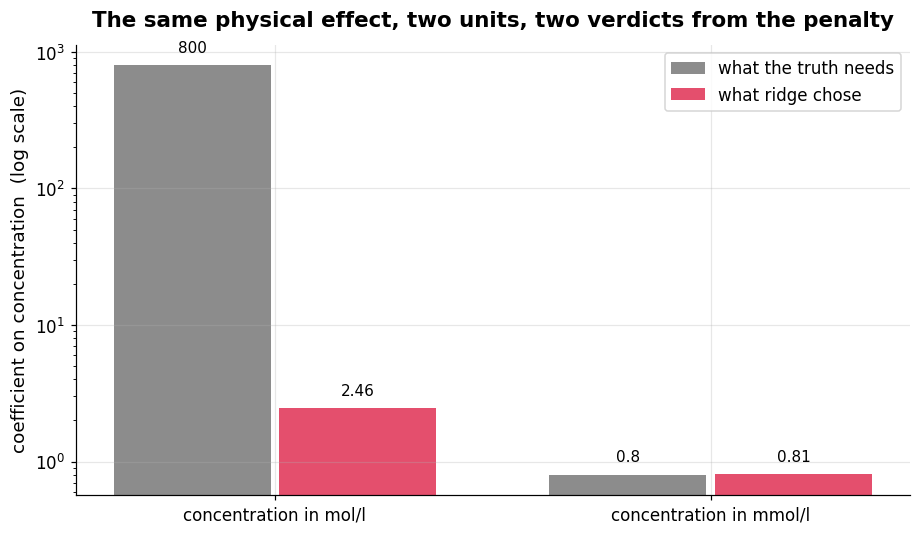

In [5]:
needed = {"mol/l": 800.0, "mmol/l": 0.8}
chosen = {name: Ridge(alpha=1.0).fit(features, measured).coef_[1]
          for name, features in [("mol/l", in_mol), ("mmol/l", in_mmol)]}

fig, axis = plt.subplots(figsize=(8.5, 5))
spots = np.arange(2)
axis.bar(spots - 0.19, [needed[u] for u in needed], 0.36, label="what the truth needs",
         color="0.55")
axis.bar(spots + 0.19, [chosen[u] for u in needed], 0.36, label="what ridge chose",
         color="crimson", alpha=0.75)
for k, unit in enumerate(needed):
    axis.text(k - 0.19, needed[unit] * 1.25, f"{needed[unit]:g}", ha="center", fontsize=10)
    axis.text(k + 0.19, chosen[unit] * 1.25, f"{chosen[unit]:.2f}", ha="center", fontsize=10)
axis.set_yscale("log")
axis.set_xticks(spots)
axis.set_xticklabels(["concentration in mol/l", "concentration in mmol/l"])
axis.set_ylabel("coefficient on concentration  (log scale)")
axis.set_title("The same physical effect, two units, two verdicts from the penalty")
axis.legend()
plt.show()

There is the mechanism, and the figure above is it on one axis. Note the logarithmic scale: the
two bars on the left differ by a factor of three hundred.

In mol/l the concentration coefficient would have to be about **800** to carry its real effect,
because the feature itself is tiny — hundredths of a mole. The penalty charges $\alpha\beta^2$, so a
coefficient of 800 costs 640,000, and ridge refuses to pay: it settles for something near 2 and the
model effectively ignores concentration altogether.

In mmol/l the identical physical effect needs a coefficient of only about **0.8**, which costs
almost nothing. The penalty barely notices it, and it survives.

So the penalty is not charging for *importance*. It is charging for the numerical size of a
coefficient, and that size is set by the unit — a choice made by whoever wrote the data file.

The fix follows directly: remove the units before applying the penalty.

In [6]:
print("prediction for the first sample, with the features standardised first:")
for name, features in [("concentration in mol/l ", in_mol), ("concentration in mmol/l", in_mmol)]:
    scaled = make_pipeline(StandardScaler(), Ridge(alpha=1.0)).fit(features, measured)
    print(f"   {name}: {scaled.predict(features[:1])[0]:8.3f}")

prediction for the first sample, with the features standardised first:
   concentration in mol/l :   -5.569
   concentration in mmol/l:   -5.569


The same answer both times.

Standardising puts every feature in units of its own standard deviation, so a coefficient now means
"the effect of moving this feature by one standard deviation" — a quantity that is comparable across
features, and unchanged by whether the file recorded moles or millimoles. Only then does a single
$\alpha$ charge all the coefficients on equal terms.

> **Always scale before regularizing**, and do it inside a pipeline, so the scaler is refitted within
> each cross-validation fold. `02C` §6.3 gave one reason to keep preprocessing in the pipeline; this
> is the second.

It also answers something `02C` §6.3 left hanging. It said ordinary least squares is unaffected by
feature scaling, which is true and remains true — the fit simply rescales the coefficient to
compensate. That freedom is exactly what the penalty removes, which is why scaling stops being
optional the moment a penalty is added.

<div class="alert alert-success">
<b>Mini-exercise 1 — How much does the unit matter?</b><br>
Using the cell above:
<br><br>
1. Express the concentration in µmol/l — a further factor of 1000 — and refit the raw ridge. What
   happens to its coefficient, and to the prediction?<br>
2. At what unit does the raw ridge fit stop ignoring the concentration?<br>
3. Confirm that the scaled pipeline is unchanged by all of this.<br>
4. Ordinary <code>LinearRegression</code> is unaffected by the choice of unit. Verify it, and explain
   in one sentence why the penalty is what breaks the equivalence.
</div>

In [7]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# 3. What ridge does to the coefficients

`02A` §8.4 fitted ten features to 442 diabetes patients and found something uncomfortable. Two of
the blood measurements, `s1` and `s2`, are correlated at about 0.90, and their fitted coefficients
came out at roughly −790 and +480: large, opposite, and not to be believed. Fitting the same model
to different halves of the data moved them wildly.

That was left as "one motivation for the regularization methods in Class 3". Here it is.

In [8]:
diabetes = load_diabetes(as_frame=True)
X_diabetes = diabetes.data
y_diabetes = diabetes.target
feature_names = list(X_diabetes.columns)

first_half, second_half = X_diabetes[:221], X_diabetes[221:]
y_first, y_second = y_diabetes[:221], y_diabetes[221:]

print(f"{'fitted on':>12}{'s1':>12}{'s2':>12}")
for label, model in [("least squares", LinearRegression()), ("ridge, alpha=1", Ridge(alpha=1.0))]:
    a = model.fit(first_half, y_first).coef_
    b = model.fit(second_half, y_second).coef_
    i1, i2 = feature_names.index("s1"), feature_names.index("s2")
    print(f"\n  {label}")
    print(f"{'first half':>12}{a[i1]:>12.1f}{a[i2]:>12.1f}")
    print(f"{'second half':>12}{b[i1]:>12.1f}{b[i2]:>12.1f}")

   fitted on          s1          s2

  least squares
  first half      -829.3       385.8
 second half      -735.0       543.5

  ridge, alpha=1
  first half         4.5       -21.5
 second half        36.6        16.9


Least squares gives coefficients in the hundreds that change by a hundred or more between the two
halves of the same dataset. Ridge gives small coefficients that stay small.

> **Why is there no scaler here, two cells after "always scale"?** Because these ten features
> already share one scale. `02A` §8.2 noted that the dataset's authors centred them; they also gave
> every column the same standard deviation, 0.0476. A single $\alpha$ therefore already charges them
> on equal terms, and the unfairness section 2 was about cannot arise. Keeping the raw units also
> lets these coefficients be read against `02A` §8.4's.
>
> One thing does not carry over. **The $\alpha$ here is not the $\alpha$ of the coefficient paths
> below**, which are drawn on standardised features. A common scale is not unit variance: 0.0476 is
> about 21 times smaller, so raw coefficients come out about 21 times larger, the sum of their
> squares about 441 times larger, and the same $\alpha = 1$ bites far harder. That is why ridge
> almost annihilates the coefficients here while the path at $\alpha = 1$ still shows substantial
> ones. Between the two, compare shapes and never numbers.

This is variance reduction seen at the level of the parameters rather than the predictions. When two
features move together, least squares is nearly indifferent between "large positive on one, large
negative on the other" and any similar pair — the predictions barely change, so the data cannot
choose. The penalty breaks the tie, by preferring the smallest coefficients among all the
near-equivalent solutions.

Note what has and has not been fixed. The coefficients are now stable, but they are also heavily
shrunk, and a shrunk coefficient is not an unbiased estimate of a physical effect. Regularization
buys stability with bias — precisely the trade `03B` described.

A **coefficient path** shows the whole trade at once: every coefficient as a function of $\alpha$.

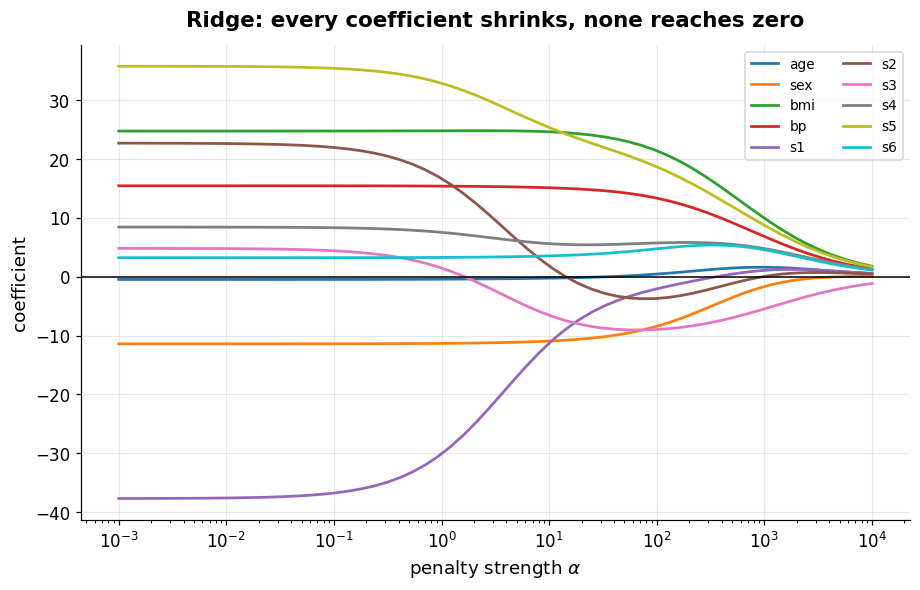

In [9]:
alphas = np.logspace(-3, 4, 60)
X_scaled = StandardScaler().fit_transform(X_diabetes)

ridge_paths = np.array([Ridge(alpha=a).fit(X_scaled, y_diabetes).coef_ for a in alphas])

plt.figure(figsize=(8.5, 5.5))
for j, name in enumerate(feature_names):
    plt.plot(alphas, ridge_paths[:, j], linewidth=1.8, label=name)
plt.xscale("log")
plt.axhline(0, color="black", linewidth=1)
plt.xlabel(r"penalty strength $\alpha$")
plt.ylabel("coefficient")
plt.title("Ridge: every coefficient shrinks, none reaches zero")
plt.legend(ncol=2, fontsize=9)
plt.show()

Read it from left to right. At small $\alpha$ the coefficients are the least-squares ones — large,
and including the `s1`/`s2` pair pulling hard in opposite directions. As the penalty grows they are
drawn together and towards zero, the widest excursions collapsing first. At the far right everything
is nearly zero and the model predicts almost the same value for every patient.

Notice one thing for later: **no coefficient ever reaches exactly zero.** Ridge shrinks
indefinitely without eliminating. Whether that is what you want depends on the question.

# 4. Lasso, and why the shapes differ

Section 3 ended on an observation: ridge never quite eliminates anything. A different penalty does.
**Lasso** replaces the sum of squares with the sum of absolute values:

$$
L(\boldsymbol{\beta}) \;=\; \sum_i \bigl(y_i - \hat{y}_i\bigr)^2
\;+\; \alpha \sum_j \bigl|\beta_j\bigr|
$$

One character of difference, and a quite different behaviour. Putting the two paths side by side is
the clearest way to see it.

Why the difference? The short version is about the shape of the penalty near zero, and the two
shapes are already drawn in `02A` §9 — there as functions of a *residual* rather than of a
coefficient, but $x^2$ against $\lvert x \rvert$ is the same pair of curves whatever $x$ denotes.
Look at that figure near the origin rather than far out. The derivative of
$\beta^2$ is $2\beta$, which vanishes as $\beta$ approaches zero — so the pressure to shrink fades
exactly when the coefficient is nearly gone, and it never arrives. The derivative of $|\beta|$ is
$\pm 1$ regardless of how small $\beta$ is, so the pressure never fades, and a coefficient whose
contribution to the fit is worth less than that constant pressure is pushed all the way to zero and
held there.

| | Penalty | Effect | Use when |
|---|---|---|---|
| **Ridge** | $\alpha\sum\beta_j^2$ | shrinks all, keeps all | features are correlated, and you want stability |
| **Lasso** | $\alpha\sum\lvert\beta_j\rvert$ | shrinks, and zeroes some | you want a small, interpretable subset |


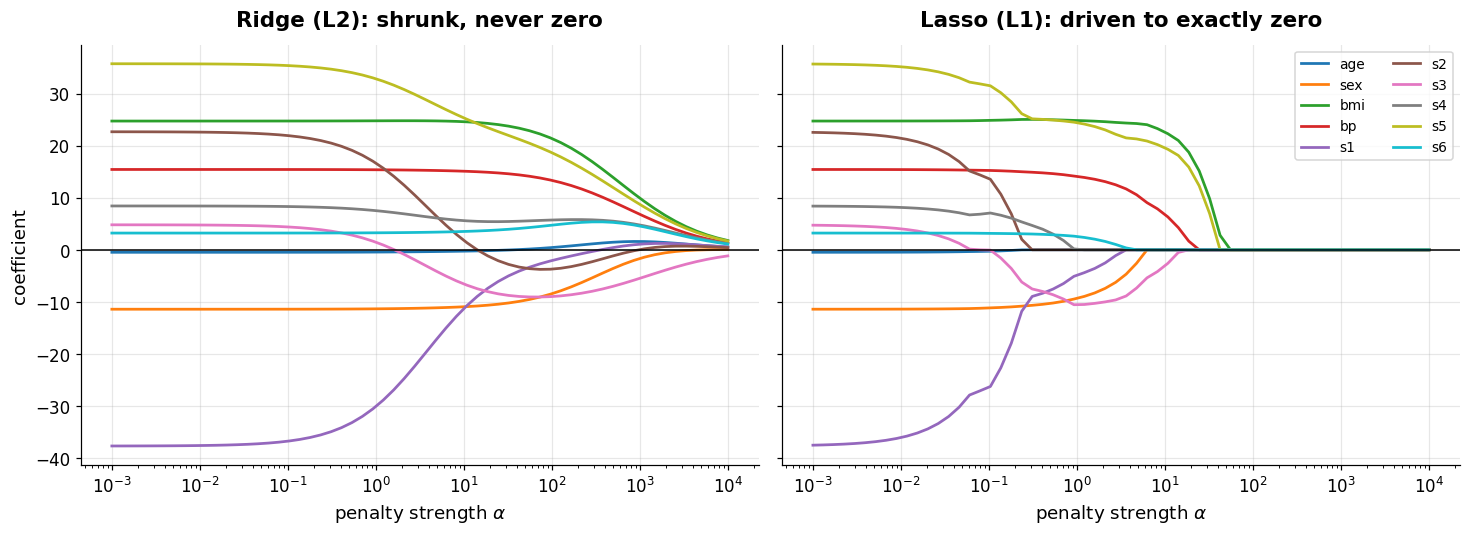

     alpha   non-zero coefficients (lasso)
         1                               7
         5                               5
        10                               4
        20                               3
        30                               2
        40                               2


In [10]:
lasso_paths = np.array([Lasso(alpha=a, max_iter=50000).fit(X_scaled, y_diabetes).coef_
                        for a in alphas])

fig, (ridge_axis, lasso_axis) = plt.subplots(1, 2, figsize=(13.5, 5), sharey=True)
for axis, paths, title in [(ridge_axis, ridge_paths, "Ridge (L2): shrunk, never zero"),
                           (lasso_axis, lasso_paths, "Lasso (L1): driven to exactly zero")]:
    for j, name in enumerate(feature_names):
        axis.plot(alphas, paths[:, j], linewidth=1.8, label=name)
    axis.set_xscale("log")
    axis.axhline(0, color="black", linewidth=1)
    axis.set_xlabel(r"penalty strength $\alpha$")
    axis.set_title(title)

ridge_axis.set_ylabel("coefficient")
lasso_axis.legend(ncol=2, fontsize=9, loc="upper right")
plt.show()

print(f"{'alpha':>10}{'non-zero coefficients (lasso)':>32}")
for a in [1, 5, 10, 20, 30, 40]:
    print(f"{a:>10}{np.sum(Lasso(alpha=a, max_iter=50000).fit(X_scaled, y_diabetes).coef_ != 0):>32}")

Ridge, on the left, shrinks everything smoothly and keeps everything. Lasso, on the right, drives
coefficients to **exactly** zero one after another, and the printed counts show the model losing
features as $\alpha$ rises: seven at $\alpha = 1$, five at 5, three at 20, two at 30.

That makes lasso a method of **feature selection** as well as regularization: it chooses a subset
and reports the rest as irrelevant. A model with three non-zero coefficients out of ten is one you
can describe in a sentence.

A caution on lasso with correlated features. Given `s1` and `s2` at correlation 0.90, lasso will
typically keep one and zero the other. How firmly it prefers the one it picked is worth measuring
rather than assuming, so the next cell measures it.

Measuring it needs many datasets and we have one, so the cell below manufactures stand-ins. It draws
442 patients from our 442 **with replacement** — so some are picked twice or three times and others
not at all — and refits the lasso on each draw. Thirty such draws give thirty plausible alternative
datasets, built from nothing but the data we already had.

That technique is the **bootstrap**. It is used here only for the convenience of the example, as a
quick way to ask what a different sample of the same patients would have given us. `04B` §2
introduces it properly, where it stops being a way of *checking* a model and becomes the basis of
one.

In [11]:
resample = np.random.default_rng(0)
s1_index, s2_index = feature_names.index("s1"), feature_names.index("s2")
targets = np.asarray(y_diabetes)

fitted = Lasso(alpha=1, max_iter=50000).fit(X_scaled, y_diabetes).coef_
print(f"lasso on all 442 patients, alpha = 1:"
      f"   s1 {fitted[s1_index]:.2f}   s2 {fitted[s2_index]:.2f}")

kept_s1 = kept_s2 = kept_both = 0
for _ in range(30):
    rows = resample.integers(0, len(targets), len(targets))
    c = Lasso(alpha=1, max_iter=50000).fit(X_scaled[rows], targets[rows]).coef_
    in1, in2 = c[s1_index] != 0, c[s2_index] != 0
    kept_s1 += in1; kept_s2 += in2; kept_both += (in1 and in2)

print(f"\nover 30 bootstrap resamples:   s1 kept {kept_s1}/30   s2 kept {kept_s2}/30"
      f"   both {kept_both}/30")

lasso on all 442 patients, alpha = 1:   s1 -4.84   s2 -0.00

over 30 bootstrap resamples:   s1 kept 25/30   s2 kept 5/30   both 2/30


On the full dataset lasso keeps `s1` and discards `s2`, which reads like a finding: one blood
measurement matters, the other does not.

The resampling says otherwise. Refit on bootstrap resamples of the same patients and `s1` survives
most of the time, `s2` occasionally, and the two together only rarely. They are nearly
interchangeable, and lasso is choosing between them on evidence far too thin to bear the choice.

### Elastic net: both penalties at once

**Elastic net** is the usual response. It applies both penalties at once:

$$
L(\boldsymbol{\beta}) \;=\; \sum_i \bigl(y_i - \hat{y}_i\bigr)^2
\;+\; \alpha \Bigl[\, \rho \sum_j \lvert\beta_j\rvert
\;+\; \tfrac{1 - \rho}{2} \sum_j \beta_j^2 \,\Bigr]
$$

where $\rho$ is `l1_ratio`. At $\rho = 1$ it is lasso; at $\rho = 0$ it is ridge; in between it does
some of each. Run the same comparison on it, and draw its path beside the other two.

elastic net on all 442 patients, alpha = 1:   s1 -0.24   s2 -2.37

over 30 bootstrap resamples:   s1 kept 22/30   s2 kept 29/30   both 21/30


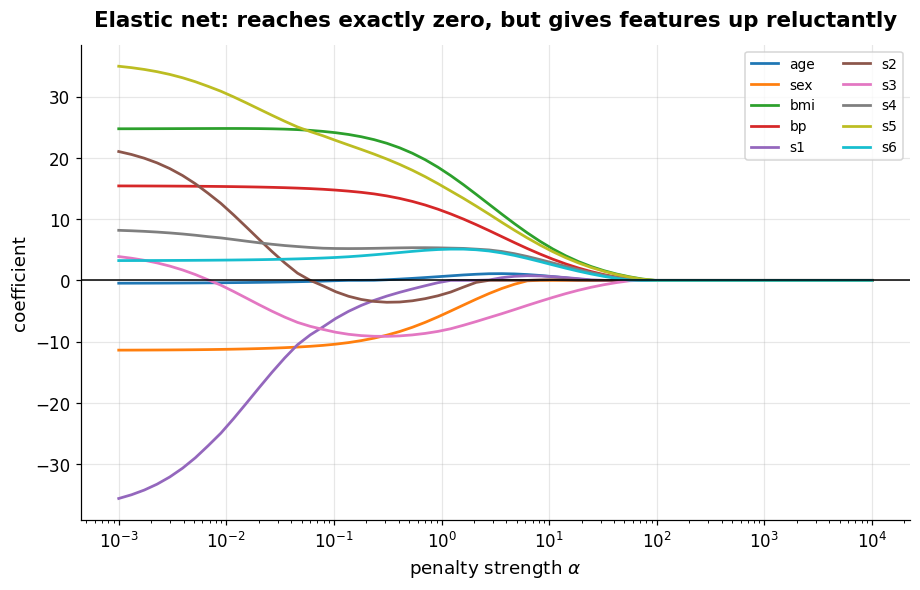

   alpha     lasso   elastic net      features kept
       1         7            10
       5         5             9
      10         4             9
      20         3             8
      30         2             6
      60         0             4


In [12]:
elastic_paths = np.array([ElasticNet(alpha=a, l1_ratio=0.5, max_iter=50000)
                          .fit(X_scaled, y_diabetes).coef_ for a in alphas])

fitted_net = ElasticNet(alpha=1, l1_ratio=0.5, max_iter=50000).fit(X_scaled, y_diabetes).coef_
print(f"elastic net on all 442 patients, alpha = 1:"
      f"   s1 {fitted_net[s1_index]:.2f}   s2 {fitted_net[s2_index]:.2f}")

resample = np.random.default_rng(0)      # re-seeded: the same 30 resamples lasso saw
kept_s1 = kept_s2 = kept_both = 0
for _ in range(30):
    rows = resample.integers(0, len(targets), len(targets))
    c = ElasticNet(alpha=1, l1_ratio=0.5, max_iter=50000).fit(X_scaled[rows], targets[rows]).coef_
    in1, in2 = c[s1_index] != 0, c[s2_index] != 0
    kept_s1 += in1; kept_s2 += in2; kept_both += (in1 and in2)

print(f"\nover 30 bootstrap resamples:   s1 kept {kept_s1}/30   s2 kept {kept_s2}/30"
      f"   both {kept_both}/30")

plt.figure(figsize=(8.5, 5.5))
for j, name in enumerate(feature_names):
    plt.plot(alphas, elastic_paths[:, j], linewidth=1.8, label=name)
plt.xscale("log")
plt.axhline(0, color="black", linewidth=1)
plt.xlabel(r"penalty strength $\alpha$")
plt.ylabel("coefficient")
plt.title("Elastic net: reaches exactly zero, but gives features up reluctantly")
plt.legend(ncol=2, fontsize=9)
plt.show()

print(f"{'alpha':>8}{'lasso':>10}{'elastic net':>14}      features kept")
for a in [1, 5, 10, 20, 30, 60]:
    by_lasso = np.sum(Lasso(alpha=a, max_iter=50000).fit(X_scaled, y_diabetes).coef_ != 0)
    by_net = np.sum(ElasticNet(alpha=a, l1_ratio=0.5, max_iter=50000)
                    .fit(X_scaled, y_diabetes).coef_ != 0)
    print(f"{a:>8}{by_lasso:>10}{by_net:>14}")

Elastic net keeps both members of the pair on the full data, and in 21 of 30 resamples — the *same*
30 that lasso saw, so the two methods are being compared on identical data — where lasso kept both
in 2. The L2 half rewards spreading a shared effect across
correlated features rather than loading it all onto whichever fitted marginally better — and note
that on the full data it leans towards `s2`, the one lasso discarded, which makes the point about
arbitrariness twice over.

That behaviour is called the **grouping effect**: correlated features tend to enter and leave the
model together. Reach for elastic net when you want sparsity but suspect the features come in
correlated groups — which, in measured scientific data, they usually do.

The path shows the other half of its character, and in behaviour it sits between the two panels
above. Like lasso, and unlike ridge, its coefficients reach **exactly** zero. But it gives features
up far more reluctantly: at $\alpha = 20$ lasso is down to three features while elastic net still
holds eight, and where lasso has nothing left at $\alpha = 60$ elastic net still has four. Sparsity, but reached by a longer road — which is the point, since
the road is where the arbitrary choices get made.

> `l1_ratio` is a second hyperparameter. It joins $\alpha$ in the search of section 5 rather than
> being guessed; `GridSearchCV` takes a grid over both at once.

<div class="alert alert-success">
<b>Mini-exercise 2 — Reading the paths</b><br>
From the figure and the printed counts:
<br><br>
1. Which feature keeps the largest coefficient longest under lasso? What does that suggest?<br>
2. At roughly what $\alpha$ does lasso reduce the model to three features?<br>
3. Fit a lasso at that $\alpha$ and list the surviving features.<br>
4. Now fit it again on only the first 221 patients. Is the surviving set the same? What does your
answer imply about reporting a lasso-selected feature list as a finding?
</div>

In [13]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# 5. Choosing $\alpha$

Nothing so far says which $\alpha$ to use, and no amount of staring at the paths will. It is a
**hyperparameter** — chosen before fitting, not learned from the fit — exactly like the polynomial
degree of `02C` §1.2, and it is chosen the same way: by cross-validation.

`02C` warned that any preprocessing must live inside the pipeline so that it is refitted within each
fold. That warning becomes essential here, because the scaler is now load-bearing: a scaler fitted
on all the data before cross-validation would leak the test folds into the penalty.

`GridSearchCV` does the search. Give it a pipeline, a grid of values, and a number of folds, and it
cross-validates every setting and refits the best one on all the data.

We run it on 60 of the 442 patients. Ten coefficients estimated from 60 measurements is the regime
`03B` called variance-dominated, which is the situation a penalty exists for.

60 patients, 10 features
   cross-validated MSE, no penalty:    5302.0
   cross-validated MSE, best ridge:    3606.7   (alpha = 20.3)
   error removed by the penalty:        32.0 %


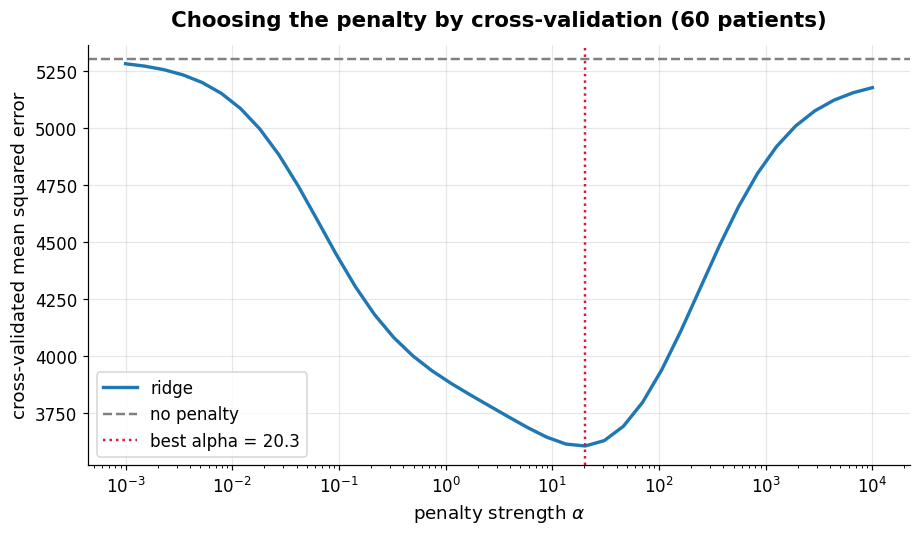

In [14]:
small = 60
X_small, y_small = X_diabetes[:small], y_diabetes[:small]
alpha_grid = np.logspace(-3, 4, 40)

search = GridSearchCV(
    make_pipeline(StandardScaler(), Ridge()),
    param_grid={"ridge__alpha": alpha_grid},
    cv=5,
    scoring="neg_mean_squared_error",
)
search.fit(X_small, y_small)

best_alpha = search.best_params_["ridge__alpha"]
best_mse = -search.best_score_
plain = -cross_val_score(LinearRegression(), X_small, y_small,
                         cv=5, scoring="neg_mean_squared_error").mean()

print(f"{small} patients, 10 features")
print(f"   cross-validated MSE, no penalty:  {plain:8.1f}")
print(f"   cross-validated MSE, best ridge:  {best_mse:8.1f}   (alpha = {best_alpha:.1f})")
print(f"   error removed by the penalty:     {100 * (1 - best_mse / plain):7.1f} %")

plt.figure(figsize=(8.5, 5))
plt.plot(alpha_grid, -search.cv_results_["mean_test_score"], linewidth=2.2, label="ridge")
plt.axhline(plain, color="gray", linestyle="--", linewidth=1.6, label="no penalty")
plt.axvline(best_alpha, color="crimson", linestyle=":", linewidth=1.6,
            label=f"best alpha = {best_alpha:.1f}")
plt.xscale("log")
plt.xlabel(r"penalty strength $\alpha$")
plt.ylabel("cross-validated mean squared error")
plt.title(f"Choosing the penalty by cross-validation ({small} patients)")
plt.legend()
plt.show()

The curve has the shape `03B` taught us to expect, and both ends are bad for the reasons that
notebook gave. At $\alpha \to 0$, on the left, the model is unpenalised: it fits 60 points with ten
free coefficients and pays for that in variance. At large $\alpha$, on the right, the coefficients
are crushed towards zero and the model is too rigid to follow the data — underfitting, arrived at by
a different route. Between the two, cross-validation found a setting that removes about a third of
the error, without ever seeing the truth.

Note the syntax `ridge__alpha`: a double underscore, naming first the step in the pipeline and then
the parameter within it. That is how `GridSearchCV` reaches inside a pipeline, and it is why
`make_pipeline`'s automatic step names — `ridge`, `standardscaler` — matter in practice.

**When the penalty buys nothing.** That gain was not free improvement; it came from somewhere
specific. A penalty removes **variance** — the part of the error caused by coefficients that move
when the sample moves — and pays for the removal in bias. Where there is a lot of variance the trade
is worth making. Where there is little, there is nothing to remove, and the bias is paid for nothing.

So the same code on all 442 patients should behave differently, because ten coefficients estimated
from 442 measurements are far steadier than the same ten from 60. The cell below measures that
steadiness first — the spread of each unpenalised coefficient across the bootstrap resamples of section 4 — and then
runs the identical search.

spread of the unpenalised coefficients across resamples:
    60 patients:     415


   442 patients:     113



all 442 patients, 10 features
   cross-validated MSE, no penalty:    2993.1
   cross-validated MSE, best ridge:    2993.0   (alpha = 0.22)
   error removed by the penalty:         0.0 %


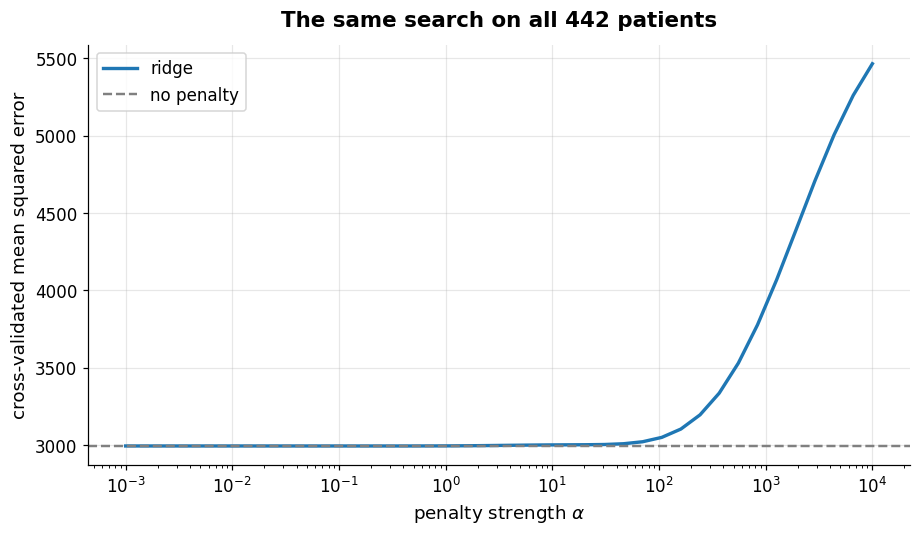

In [15]:
def coefficient_spread(features, target, draws=200):
    """Median, over the ten coefficients, of how much each moves across resamples."""
    boot = np.random.default_rng(7)
    n = len(target)
    fits = []
    for _ in range(draws):
        resample = boot.integers(0, n, n)
        fits.append(LinearRegression().fit(features.iloc[resample], target.iloc[resample]).coef_)
    return np.median(np.std(fits, axis=0))

print("spread of the unpenalised coefficients across resamples:")
print(f"   {small:>3} patients: {coefficient_spread(X_small, y_small):7.0f}")
print(f"   {len(y_diabetes):>3} patients: {coefficient_spread(X_diabetes, y_diabetes):7.0f}")

search_full = GridSearchCV(make_pipeline(StandardScaler(), Ridge()),
                           param_grid={"ridge__alpha": alpha_grid}, cv=5,
                           scoring="neg_mean_squared_error")
search_full.fit(X_diabetes, y_diabetes)

best_full = -search_full.best_score_
plain_full = -cross_val_score(LinearRegression(), X_diabetes, y_diabetes,
                              cv=5, scoring="neg_mean_squared_error").mean()

print()
print(f"all {len(y_diabetes)} patients, 10 features")
print(f"   cross-validated MSE, no penalty:  {plain_full:8.1f}")
print(f"   cross-validated MSE, best ridge:  {best_full:8.1f}   "
      f"(alpha = {search_full.best_params_['ridge__alpha']:.2f})")
print(f"   error removed by the penalty:     {100 * (1 - best_full / plain_full):7.1f} %")

plt.figure(figsize=(8.5, 5))
plt.plot(alpha_grid, -search_full.cv_results_["mean_test_score"], linewidth=2.2, label="ridge")
plt.axhline(plain_full, color="gray", linestyle="--", linewidth=1.6, label="no penalty")
plt.xscale("log")
plt.xlabel(r"penalty strength $\alpha$")
plt.ylabel("cross-validated mean squared error")
plt.title(f"The same search on all {len(y_diabetes)} patients")
plt.legend()
plt.show()

Same code, same features, same ten coefficients; only the amount of data changed, and it shows up
twice. The unpenalised coefficients move about four times as much at 60 patients as at 442. And
where there was that much movement the penalty removed a third of the error, while here it removes
none — the best $\alpha$ the search can find beats no penalty only in the first decimal place, which
is the search reporting that it found nothing to do.

The curve makes the point more sharply than the numbers do. It has no dip at all: it sits flat at
the unpenalised error until the penalty grows large enough to do damage, and then only rises. Every
$\alpha$ worth the name is either neutral or harmful.

That is `03B` restated in one section. **A penalty trades bias for variance, so it can only help
where variance is what you are paying for.** On the full dataset the error that remains is noise and
model bias, and shrinking coefficients reaches neither; insist on a penalty anyway and the right-hand
half of the curve is what you get. Regularization is not an improvement you apply by default — it is
insurance, and it pays exactly when the parameters are many relative to the data.

> Which is why it becomes indispensable rather than optional in Class 7: a neural network may have
> more parameters than the dataset has points, and is regularized heavily as a matter of course.
>
> Be careful with the reason, though. The classical story above — more parameters, more variance —
> is the right account of *this* notebook's models, and it stops being reliable once a model has
> enough parameters to interpolate the training data exactly. Past that point the test error of a
> large network often falls again rather than continuing to rise. Class 8 returns to it; take the
> practical conclusion here and not the extrapolation.

# 6. The penalty that was there all along

One debt remains, from `02B` §6.

`scikit-learn`'s `LogisticRegression` is regularized **by default**. Every classifier fitted in
`02B` carried an L2 penalty, and the notebook flagged the fact and deferred it to here.

Its strength is set by `C`, which is the **inverse** of the $\alpha$ used above:

$$
C \;=\; \frac{1}{\alpha}
$$

So small `C` means strong regularization, and large `C` means weak. The default is `C=1.0`, which is
a moderate penalty rather than none — and it means that "the model that minimises cross-entropy",
as `02B` §5 put it, was always a slight simplification.

In [16]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
try:                                        # the fallback pattern of 01C 3.2
    iris = pd.read_csv(url)
except Exception:                           # no network: the copy bundled with scikit-learn
    from sklearn.datasets import load_iris
    bundled = load_iris(as_frame=True)
    iris = bundled.frame.rename(columns=lambda name: name.replace(" (cm)", "").replace(" ", "_"))
    iris["species"] = iris.pop("target").map(dict(enumerate(bundled.target_names)))
pair = iris[iris["species"].isin(["versicolor", "virginica"])]
X_pair = pair[["petal_length"]]      # one feature, exactly as in 02B section 6
y_pair = (pair["species"] == "virginica").astype(int)

print(f"{'C':>10}{'slope (petal length)':>24}{'intercept':>12}{'accuracy':>11}")
for C in [0.01, 0.1, 1.0, 100.0, 10000.0]:
    model = LogisticRegression(C=C).fit(X_pair, y_pair)
    print(f"{C:>10}{model.coef_[0][0]:>24.2f}{model.intercept_[0]:>12.2f}"
          f"{model.score(X_pair, y_pair):>11.3f}")

         C    slope (petal length)   intercept   accuracy
      0.01                    0.28       -1.36      0.920
       0.1                    1.37       -6.70      0.930
       1.0                    3.59      -17.51      0.930
     100.0                    8.50      -41.33      0.930
   10000.0                    8.99      -43.70      0.930


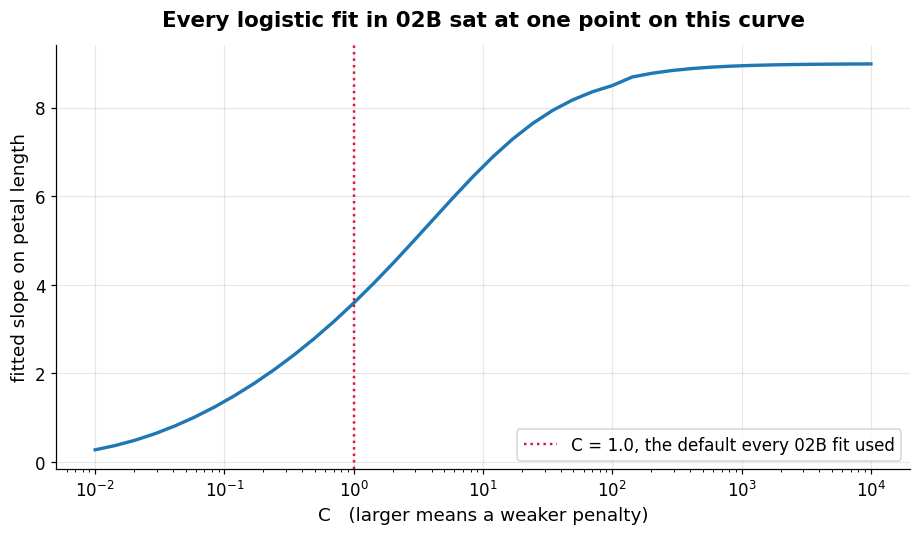

In [17]:
strengths = np.logspace(-2, 4, 40)
slopes = [LogisticRegression(C=strength).fit(X_pair, y_pair).coef_[0][0]
          for strength in strengths]

plt.figure(figsize=(8.5, 5))
plt.plot(strengths, slopes, linewidth=2.2)
plt.axvline(1.0, color="crimson", linestyle=":", linewidth=1.6,
            label="C = 1.0, the default every 02B fit used")
plt.xscale("log")
plt.xlabel("C   (larger means a weaker penalty)")
plt.ylabel("fitted slope on petal length")
plt.title("Every logistic fit in 02B sat at one point on this curve")
plt.legend()
plt.show()

As `C` grows the penalty weakens and the coefficients grow. The row at `C=1.0` reproduces `02B`
§6's slope of 3.59 exactly — that notebook was reading a *penalised* coefficient without saying so.
Remove the penalty and the same data gives a slope of about 9, two and a half times larger.

The accuracy hardly moves, which is worth noticing. On this easy, well-separated problem the penalty
costs nothing in performance while keeping the coefficients modest. That is the usual situation, and
it is why the default is a penalty rather than none.

> If you ever want genuinely unpenalised logistic regression, you must ask for it: `penalty=None`.
> Reporting a coefficient from a default `LogisticRegression` as though it were a maximum-likelihood
> estimate is a small but real error.

It also completes the answer to `02B` §10.1, which said that scaling the features was the second
remedy for a fit that will not converge. Now the reason is visible: the penalty makes the coefficient
scale meaningful, so badly scaled features distort both the optimisation and the penalty at once.

# 7. Common pitfalls

**Regularizing without scaling.** Section 2. The penalty then depends on your choice of units, and
the model quietly ignores whichever feature was measured in inconvenient ones.

**Scaling outside the pipeline.** The scaler learns two numbers from the data; fitted before
splitting, those numbers carry the test set into the fit. `02C` §6.3.

**Reading shrunk coefficients as physical effects.** Ridge deliberately biases coefficients towards
zero. A ridge coefficient answers "what is a stable summary?", not "how large is this effect?".

**Reading a lasso subset as a discovery.** With correlated features the choice among them is
close to arbitrary and unstable under resampling. Report it as one of several near-equivalent
subsets, or check its stability by refitting on resampled data.

**Tuning $\alpha$ on the test set.** It is a hyperparameter like any other, and the rule from `02C`
§5 holds: the set that chose the model cannot also evaluate it.

**Assuming more regularization is safer.** The far right of section 5's 60-patient curve is as bad
as the far left. Over-penalising is underfitting, arrived at by a different route.

# 8. Applying this to your own data

Everything above is about how ridge and lasso work. This section is about **using them**: it is the
pipeline map at the top of this notebook, executed. The cell below runs in seven numbered steps,
each labelled with the map step it carries out — between them they cover map steps 2, 5, 6, 8 and 9.
Map steps 1, 3 and 4 happened before you reached this cell, and map step 10 is the *What to deliver*
block that closes the section.

**The cell's seven steps are the same whatever the model is, and only step 4 changes when the method
changes** — which is the point.

Classes 2 and 3 get cashed out here. `02C` supplies the splitting protocol, `03A` supplies the
choice of metric, and `03B` and `03C` supply the reason there is a dial to tune at all. If you have
wondered why three hours went on generalization and metrics before any of this, the cell below is
the answer.

The dataset is the diabetes cohort of `02A` §8: 442 patients, ten physiological measurements, and a
measure of disease progression a year later.

In [18]:
from sklearn.dummy import DummyRegressor          # the "no model at all" of step 3

# 1 (map step 2) — split first. Nothing above has seen the test set.  02C §6
X_train, X_test, y_train, y_test = train_test_split(
    X_diabetes, y_diabetes, test_size=0.25, random_state=0)

# 2 (map step 5) — preprocessing lives inside the pipeline, so it refits per fold.  02C §6.3
#     A penalty compares coefficients, so scaling is REQUIRED here — section 2.
estimator = make_pipeline(StandardScaler(), Ridge())

# 3 (map step 6) — a baseline, so the final number has something to beat
baseline = DummyRegressor(strategy="mean").fit(X_train, y_train).score(X_test, y_test)

# 4 (map step 8) — tune the dial by cross-validation, on the training set only.
#     THIS IS THE ONLY BLOCK THAT CHANGES WHEN THE METHOD CHANGES.
search = GridSearchCV(estimator, {"ridge__alpha": np.logspace(-3, 4, 40)},
                      cv=5, scoring="r2", n_jobs=-1)
search.fit(X_train, y_train)

# 5 (map step 8) — the cross-validated score and the SPREAD ACROSS FOLDS.
#     Not a standard error: the folds share training data, so they are correlated.
best = search.best_index_
cv_mean = search.cv_results_["mean_test_score"][best]
cv_spread = search.cv_results_["std_test_score"][best]

# 6 (map step 9) — the test set, once, at the end.  02C §5
test_score = search.score(X_test, y_test)

# 7 (map step 9) — an error bar on it, by resampling the test set.  The bootstrap of 04B §2.
boot_rng = np.random.default_rng(0)
truth = np.asarray(y_test)
predicted = search.predict(X_test)
resampled = []
for _ in range(2000):
    rows = boot_rng.integers(0, len(truth), len(truth))
    resampled.append(r2_score(truth[rows], predicted[rows]))
low, high = np.percentile(resampled, [2.5, 97.5])

print(f"{len(y_train)} training patients, {len(y_test)} test patients, "
      f"{X_diabetes.shape[1]} measurements")
print(f"\nbaseline (predict the mean) : R^2 {baseline:7.4f}")
print(f"best alpha                  : {search.best_params_['ridge__alpha']:.3f}")
print(f"cross-validated R^2         : {cv_mean:7.4f}  +/- {cv_spread:.4f}  (spread across folds)")
print(f"test R^2                    : {test_score:7.4f}  95% bootstrap "
      f"[{low:.4f}, {high:.4f}]")

331 training patients, 111 test patients, 10 measurements

baseline (predict the mean) : R^2 -0.0001
best alpha                  : 30.703
cross-validated R^2         :  0.5175  +/- 0.0434  (spread across folds)
test R^2                    :  0.3656  95% bootstrap [0.1697, 0.5078]


Read the last two lines together, because the gap between them is the lesson.

Cross-validation on the training patients said $R^2 \approx 0.52$. The test set says **0.37**. That
is not a bug and it is not overfitting in the usual sense — it is what `02C` §3 warned about, seen
from the other side: **one split is one sample.** The bootstrap interval makes the point
unarguable. On 111 patients the test $R^2$ is only pinned down to about $\pm 0.17$, so 0.37 and 0.52
are not even in conflict.

Report the interval. A single number invites a confidence the experiment does not support.

> **The spread across folds is not a standard error.** It is tempting to divide it by $\sqrt{k}$ and
> call the result one, and it is wrong: the $k$ training sets overlap heavily, so the fold scores
> are correlated and the usual formula does not apply. There is no unbiased estimator of the
> variance of $k$-fold cross-validation. Report the spread, and call it the spread.

### What to deliver — map step 10

That cell is the core of a project notebook. The report it supports is short:

- **Task and data** — predicting one-year disease progression for 442 patients from ten
  physiological measurements; 331 train, 111 test.
- **Protocol** — a single 75/25 split at `random_state=0`; the scaler inside the pipeline, so it is
  refitted within every fold; the test set touched once.
- **Baseline** — predicting the training mean, $R^2 = 0.00$ by construction.
- **Model and tuning** — ridge, with $\alpha$ chosen from 40 log-spaced values by 5-fold
  cross-validation on the training patients only. Selected $\alpha \approx 30.7$.
- **Result** — cross-validated $R^2 = 0.518$ with a fold spread of 0.043; **test $R^2 = 0.366$, 95%
  bootstrap interval [0.170, 0.508]**.
- **Metric** — $R^2$, because the audience wants "how much of the variation is accounted for"
  rather than an error in the target's units. `03A` §2.3 is the argument, and its warning applies:
  $R^2$ depends on the spread of the cohort.
- **Limits** — a shrunk coefficient is not an estimate of a physical effect (section 3), and
  section 5 showed the penalty buys nothing when the data are plentiful relative to the parameters.

**A project notebook is expected to contain a block like this.** It is what turns a fitted model
into a result.

# 9. Final exercises

<div class="alert alert-success">
<b>Exercise 1 — Ridge against degree</b><br>
`03B` chose flexibility by picking a degree; this notebook picks it with $\alpha$.
<br><br>
1. Using the polynomial data of section 1, cross-validate a degree-3 model with no penalty.<br>
2. Cross-validate a degree-9 model inside a <code>GridSearchCV</code> over $\alpha$.<br>
3. Which achieves the lower cross-validated error?<br>
4. Which would you rather report, and why? Consider what each one assumes you knew in advance.
</div>

In [19]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

<div class="alert alert-success">
<b>Exercise 2 — Lasso for interpretation</b><br>
A collaborator wants "the three measurements that matter" for diabetes progression.
<br><br>
1. Find the $\alpha$ at which lasso retains exactly three features.<br>
2. Repeat on 20 bootstrap resamples of the data, recording the surviving set each time.<br>
3. How often does the same set of three appear?<br>
4. Write two sentences you would actually send the collaborator, given what you found.
</div>

In [20]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

<div class="alert alert-success">
<b>Exercise 3 — Regularizing a classifier</b><br>
Return to the three-species iris model of `02B` §10.
<br><br>
1. Fit it at <code>C</code> values from 0.001 to 1000, recording training and cross-validated
   accuracy.<br>
2. Plot both against <code>C</code> on a log scale.<br>
3. Where does the gap between them open, and what does that gap measure?<br>
4. Does the best <code>C</code> differ from the default of 1.0 on this problem? Should you expect it
   to on a harder one?
</div>

In [21]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# Key Takeaways

- Regularization adds a penalty on coefficient size to the loss, converting flexibility from a
  discrete choice into a continuous dial that cross-validation can tune.
- It works because oscillating fits need large coefficients; charging for size makes wild fits
  expensive and so reduces variance.
- **Scale first, always, and inside a pipeline.** A penalty on coefficient size is meaningless
  while the coefficients are in incomparable units — changing mol/l to mmol/l changed the fitted
  model entirely.
- **Ridge** shrinks all coefficients and keeps all of them; **lasso** drives some to exactly zero
  and so selects features. The difference comes from the penalty's slope near zero.
- Regularization buys stability with bias. Shrunk coefficients are stable summaries, not estimates
  of physical effects, and a lasso-selected subset is not a discovery.
- $\alpha$ is a hyperparameter, chosen by cross-validation with `GridSearchCV` over a pipeline —
  the `step__parameter` syntax reaching inside it.
- **A penalty only helps where variance is what you are paying for.** The same search that removed
  a third of the error from 60 patients removed none from 442, because ten coefficients estimated
  from 442 measurements were already steady. Regularization is insurance, not free improvement.
- `LogisticRegression` is regularized by default, with `C = 1/α`. Every classifier in `02B` carried
  a penalty.

# Optional preparation for the next class

Before Class 4, students should be comfortable with:

- fitting a model inside a pipeline, and cross-validating the pipeline rather than the estimator;
- searching a hyperparameter with `GridSearchCV`;
- the bias–variance vocabulary of `03B`, and reading a validation curve.

Class 3 completes the toolkit for **linear** models: how to measure them, why they err, and how to
control that error. Class 4 changes the model. Decision trees make predictions by asking a sequence
of threshold questions rather than by weighting features — which handles the discontinuous
relationships `02A` §10 identified as beyond a basis expansion, and needs no feature scaling at all.
Random forests and gradient boosting then build many trees and combine them, using the averaging
idea that `03B`'s third exercise had you discover by hand.